# Solar Panel SVM Classifier — Model Training & Evaluation

**Author:** Florian Koenigstorfer

**Goal:** Identify the optimal HOG+SVM configuration with leakage-free grouped cross-validation, tune the F1-optimal decision threshold, and evaluate on the holdout test set.

**Data source:** `.npz` feature files in `/data/` produced by `feature_extraction.ipynb`.

> Findings informed the Master thesis of Florian Koenigstorfer.

## Introduction

This notebook trains a **HOG + SVM** binary classifier to detect solar panels in satellite image tiles. Three sub-questions are investigated in sequence:

1. Which SVM **kernel function** and regularisation **(C, γ)** are optimal?
2. Which HOG **cell/block size** combination is optimal?
3. Which number of HOG **orientation bins** is optimal?

All cross-validation uses `StratifiedGroupKFold` with `groups=original_filepath`, so the four rotational augmentations of the same source image always fall in the same fold. An F1-optimal decision threshold is then tuned on out-of-fold probabilities, and the final model is evaluated on the holdout test set at both the default (0.5) and the tuned threshold.

---
## Section 1 — Setup & Data Loading

In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sys.path.insert(0, "../src")
from model import (
    make_group_cv,
    tune_svm,
    tune_threshold,
    evaluate_on_holdout,
    run_hog_ablation,
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_confusion_matrix,
    plot_threshold_sweep,
)
from feature_extraction import load_feature_matrix, make_ablation_npz_name

FEATURES_DIR        = "../data"
FEATURES_TRAIN_PATH = "../data/features_train.npz"
FEATURES_TEST_PATH  = "../data/features_test.npz"

X_train, y_train, _, groups_train = load_feature_matrix(FEATURES_TRAIN_PATH)
X_test,  y_test,  _, _            = load_feature_matrix(FEATURES_TEST_PATH)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
print(f"\nClass balance (train) : {n_pos:,} positive / {n_neg:,} negative")
print(f"Class ratio (neg / pos): {n_neg / n_pos:.2f}")
print(f"Unique source images   : {len(set(groups_train)):,}  (each with 4 rotational copies)")

X_train : (8072, 4851)
X_test  : (1952, 4851)

Class balance (train) : 3,272 positive / 4,800 negative
Class ratio (neg / pos): 1.47
Unique source images   : 2,018  (each with 4 rotational copies)


---
## Section 2 — SVM Assumptions Check

SVMs make no distributional assumptions on features (no normality, no homoscedasticity), but they are sensitive to two things that must be addressed explicitly:

1. **Feature scale.** RBF and linear SVMs are distance-based, so unscaled features dominate the kernel. We put `StandardScaler` inside the pipeline so it is fitted only on the training folds of each split — no leakage.
2. **Class imbalance.** The dataset is imbalanced (more negatives than positives) and we are optimising F1, so we pass `class_weight="balanced"` to every `SVC` instance to reweight the hinge loss.

The class counts below confirm the imbalance that motivates the `class_weight="balanced"` choice.

,class,count,proportion
0,negative (0),4800,0.594648
1,positive (1),3272,0.405352


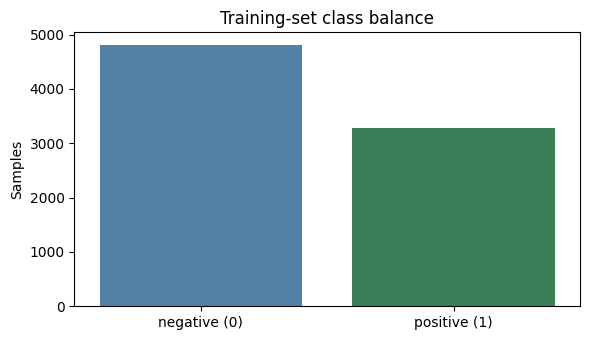

In [2]:
class_counts = pd.DataFrame({
    "class": ["negative (0)", "positive (1)"],
    "count": [int((y_train == 0).sum()), int((y_train == 1).sum())],
})
class_counts["proportion"] = class_counts["count"] / class_counts["count"].sum()
display(class_counts)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(data=class_counts, x="class", y="count",
            hue="class", palette=["steelblue", "seagreen"], legend=False, ax=ax)
ax.set_title("Training-set class balance")
ax.set_ylabel("Samples")
ax.set_xlabel("")
plt.tight_layout()

---
## Section 3 — Sub-question 1: Joint (kernel, C, γ) Tuning with Leakage-Free CV

We perform a joint grid search over kernel, C, and γ using **`StratifiedGroupKFold`** with `groups=original_filepath`.

**Why grouped CV?** Notebook 1 applies 4× rotational augmentation, so each source image produces four near-duplicate training rows. A plain `KFold` will regularly place some rotations of an image in the training fold and others in the validation fold — the model then "validates" on views of images it has already memorised, inflating CV scores. Grouping on `original_filepath` forces all four rotations into the same fold and removes the leakage.

The search combines:
- **Linear kernel:** `C ∈ np.logspace(-2, 2, 5)`
- **RBF kernel:** `C ∈ np.logspace(-2, 2, 5) × γ ∈ np.logspace(-4, 1, 6)`

Both searches pass `class_weight="balanced"` and are scored by F1.

In [3]:
cv = make_group_cv(n_splits=5)
tune_results_df, best_estimator, best_params = tune_svm(
    X_train, y_train, groups=groups_train, cv=cv, scoring="f1",
)

print("Top 10 configurations by mean F1 (StratifiedGroupKFold, 5 folds):\n")
display(tune_results_df.head(10))

print("\nBest parameters chosen:")
for k, v in best_params.items():
    print(f"  {k:8s} = {v}")
print(f"\nBest CV F1 = {tune_results_df['mean_test_score'].max():.4f}")

Top 10 configurations by mean F1 (StratifiedGroupKFold, 5 folds):



,kernel,C,gamma,mean_test_score,std_test_score,mean_fit_time,rank_test_score
0,rbf,10.00,0.0001,0.680052,0.015681,744.597208,1
1,rbf,100.00,0.0001,0.678765,0.013782,752.456070,2
2,rbf,1.00,0.0001,0.675899,0.025691,668.765705,3
3,linear,0.01,NaN,0.604270,0.008741,656.387213,1
4,linear,0.10,NaN,0.581868,0.014303,688.899730,2
5,rbf,0.10,10.0000,0.576868,0.000731,827.377747,4
6,rbf,0.01,0.0010,0.576868,0.000731,818.337502,4
7,rbf,0.01,1.0000,0.576868,0.000731,873.724244,4
8,rbf,0.01,10.0000,0.576868,0.000731,827.124293,4
9,rbf,0.01,0.1000,0.576868,0.000731,822.731034,4



Best parameters chosen:
  C        = 10.0
  gamma    = 0.0001
  kernel   = rbf

Best CV F1 = 0.6801


---
## Section 4 — Sub-question 2: Cell / Block Size Ablation

With the best kernel and (C, γ) fixed from Section 3, we cross-validate 12 cell/block configurations (ppc ∈ {4, 8, 12, 16} × cpb ∈ {2, 3, 4}). Each configuration has its own pre-computed `.npz` with its own groups array — we load the groups alongside the paths so every `cross_validate` call uses `StratifiedGroupKFold`.

In [4]:
cell_block_combos = [
    ((4,  4), (2, 2)), ((4,  4), (3, 3)), ((4,  4), (4, 4)),
    ((8,  8), (2, 2)), ((8,  8), (3, 3)), ((8,  8), (4, 4)),
    ((12,12), (2, 2)), ((12,12), (3, 3)), ((12,12), (4, 4)),
    ((16,16), (2, 2)), ((16,16), (3, 3)), ((16,16), (4, 4)),
]
cell_block_configs = []
cell_block_groups = []
for ppc, cpb in cell_block_combos:
    path = make_ablation_npz_name(FEATURES_DIR, ppc, cpb, 11)
    cell_block_configs.append({
        "path": path, "label": f"ppc={ppc[0]},cpb={cpb[0]}",
        "pixels_per_cell": ppc, "cells_per_block": cpb, "orientations": 11,
    })
    _, _, _, grp = load_feature_matrix(path)
    cell_block_groups.append(grp)

cell_block_results_df = run_hog_ablation(cell_block_configs, cell_block_groups, best_params, cv=cv)
print("Cell/Block Ablation Results (sorted by mean F1, descending):\n")
display(cell_block_results_df)

HOG ablation:   0%|          | 0/12 [00:00<?, ?it/s]

Cell/Block Ablation Results (sorted by mean F1, descending):



,label,pixels_per_cell,cells_per_block,orientations,n_samples,n_features,mean_f1,std_f1,mean_roc_auc,std_roc_auc,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall
0,"ppc=8,cpb=4","(8, 8)","(4, 4)",11,8072,6336,0.691584,0.013336,0.824686,0.016100,0.757553,0.009660,0.713907,0.013182,0.670799,0.017321
1,"ppc=12,cpb=4","(12, 12)","(4, 4)",11,8072,1584,0.684076,0.015136,0.807133,0.019603,0.727445,0.014445,0.645712,0.019476,0.727944,0.022101
2,"ppc=12,cpb=3","(12, 12)","(3, 3)",11,8072,1584,0.681699,0.016320,0.804762,0.023504,0.725712,0.015257,0.644092,0.020001,0.724574,0.022446
3,"ppc=8,cpb=3","(8, 8)","(3, 3)",11,8072,4851,0.680052,0.015681,0.812480,0.016116,0.746279,0.014293,0.696296,0.023215,0.664990,0.016645
4,"ppc=8,cpb=2","(8, 8)","(2, 2)",11,8072,2816,0.667503,0.020626,0.795391,0.016256,0.732892,0.015409,0.673974,0.022645,0.661900,0.028979
5,"ppc=12,cpb=2","(12, 12)","(2, 2)",11,8072,1100,0.659486,0.026277,0.777778,0.027531,0.708484,0.016891,0.625738,0.017093,0.698234,0.045281
6,"ppc=16,cpb=3","(16, 16)","(3, 3)",11,8072,396,0.635356,0.027461,0.746233,0.026616,0.674295,0.020468,0.581291,0.019954,0.701306,0.042698
7,"ppc=16,cpb=2","(16, 16)","(2, 2)",11,8072,396,0.629590,0.030067,0.743209,0.030989,0.670086,0.023706,0.577588,0.023662,0.693035,0.046737
8,"ppc=16,cpb=4","(16, 16)","(4, 4)",11,8072,176,0.595570,0.026989,0.702012,0.026469,0.651753,0.017514,0.562319,0.017993,0.634075,0.043448
9,"ppc=4,cpb=2","(4, 4)","(2, 2)",11,8072,12716,0.575366,0.045023,0.758083,0.032285,0.702155,0.028769,0.680352,0.046195,0.498666,0.043551


---
## Section 5 — Sub-question 3: Orientation Bin Ablation

Same pattern for orientation bin counts ∈ {6, 8, 9, 11, 13, 18}, holding ppc=8×8 and cpb=3×3 fixed.

In [5]:
orientation_values = [6, 8, 9, 11, 13, 18]
orientation_configs = []
orientation_groups = []
for ori in orientation_values:
    path = make_ablation_npz_name(FEATURES_DIR, (8, 8), (3, 3), ori)
    orientation_configs.append({
        "path": path, "label": f"ori={ori}",
        "pixels_per_cell": (8, 8), "cells_per_block": (3, 3), "orientations": ori,
    })
    _, _, _, grp = load_feature_matrix(path)
    orientation_groups.append(grp)

orientation_results_df = run_hog_ablation(orientation_configs, orientation_groups, best_params, cv=cv)
print("Orientation Ablation Results (sorted by mean F1, descending):\n")
display(orientation_results_df)

HOG ablation:   0%|          | 0/6 [00:00<?, ?it/s]

Orientation Ablation Results (sorted by mean F1, descending):



,label,pixels_per_cell,cells_per_block,orientations,n_samples,n_features,mean_f1,std_f1,mean_roc_auc,std_roc_auc,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall
0,ori=6,"(8, 8)","(3, 3)",6,8072,2646,0.691127,0.015471,0.814773,0.019002,0.743553,0.013354,0.675848,0.020250,0.708054,0.026374
1,ori=8,"(8, 8)","(3, 3)",8,8072,3528,0.685038,0.018290,0.810696,0.015598,0.744542,0.012548,0.684654,0.015675,0.686047,0.028758
2,ori=9,"(8, 8)","(3, 3)",9,8072,3969,0.684421,0.010104,0.811455,0.017175,0.746900,0.006054,0.692050,0.010837,0.677504,0.021249
3,ori=11,"(8, 8)","(3, 3)",11,8072,4851,0.680052,0.015681,0.812480,0.016116,0.746279,0.014293,0.696296,0.023215,0.664990,0.016645
4,ori=18,"(8, 8)","(3, 3)",18,8072,7938,0.675800,0.018100,0.809249,0.020934,0.748259,0.011251,0.707034,0.017556,0.648141,0.030459
5,ori=13,"(8, 8)","(3, 3)",13,8072,5733,0.672113,0.019183,0.810484,0.015760,0.744417,0.012221,0.699903,0.015541,0.646927,0.027649


---
## Section 6 — Threshold Tuning

We sweep decision thresholds over `np.linspace(0.05, 0.95, 91)` applied to out-of-fold positive-class probabilities (obtained via `cross_val_predict` with the same `StratifiedGroupKFold` splitter) and pick the threshold that maximises F1. This keeps the threshold selection honest: it is chosen on held-out folds, not on the training predictions of the refit model.

F1-optimal threshold : 0.36
  OOF F1        : 0.6987
  OOF precision : 0.6280
  OOF recall    : 0.7873


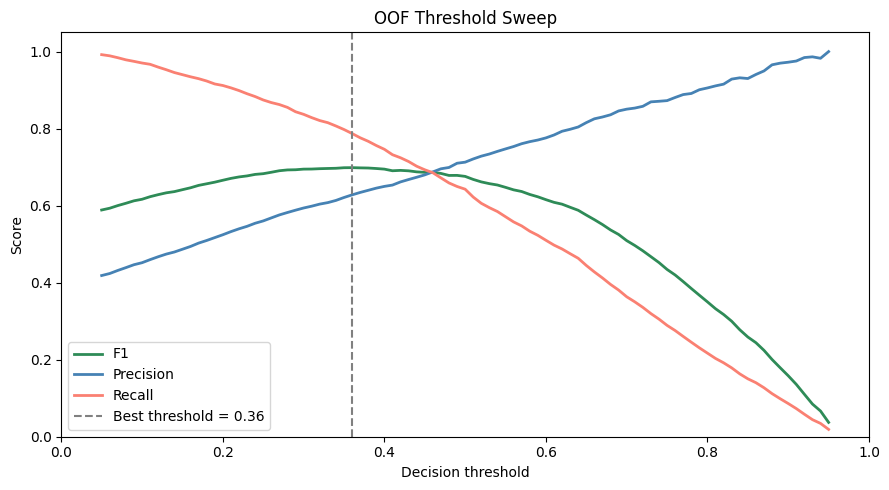

In [6]:
best_threshold, threshold_df = tune_threshold(
    best_estimator, X_train, y_train, groups=groups_train, cv=cv,
)

best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print(f"F1-optimal threshold : {best_threshold:.2f}")
print(f"  OOF F1        : {best_row['f1']:.4f}")
print(f"  OOF precision : {best_row['precision']:.4f}")
print(f"  OOF recall    : {best_row['recall']:.4f}")

plot_threshold_sweep(threshold_df)
plt.tight_layout()

---
## Section 7 — Train Final Model & Holdout Evaluation

`best_estimator` was refit on the full training set inside `GridSearchCV(refit=True)`, so it is already the final model. We evaluate it on the holdout set twice:

1. at the default threshold **0.5**,
2. at the tuned threshold from Section 6.

Both metric dicts are displayed side by side. Plots (confusion matrix, ROC, PR) are drawn for the tuned-threshold evaluation.

,holdout @ 0.5,holdout @ 0.36
metric,,
accuracy,0.7649,0.7357
precision,0.7096,0.6247
recall,0.6596,0.7859
f1,0.6837,0.6961
roc_auc,0.8275,0.8275


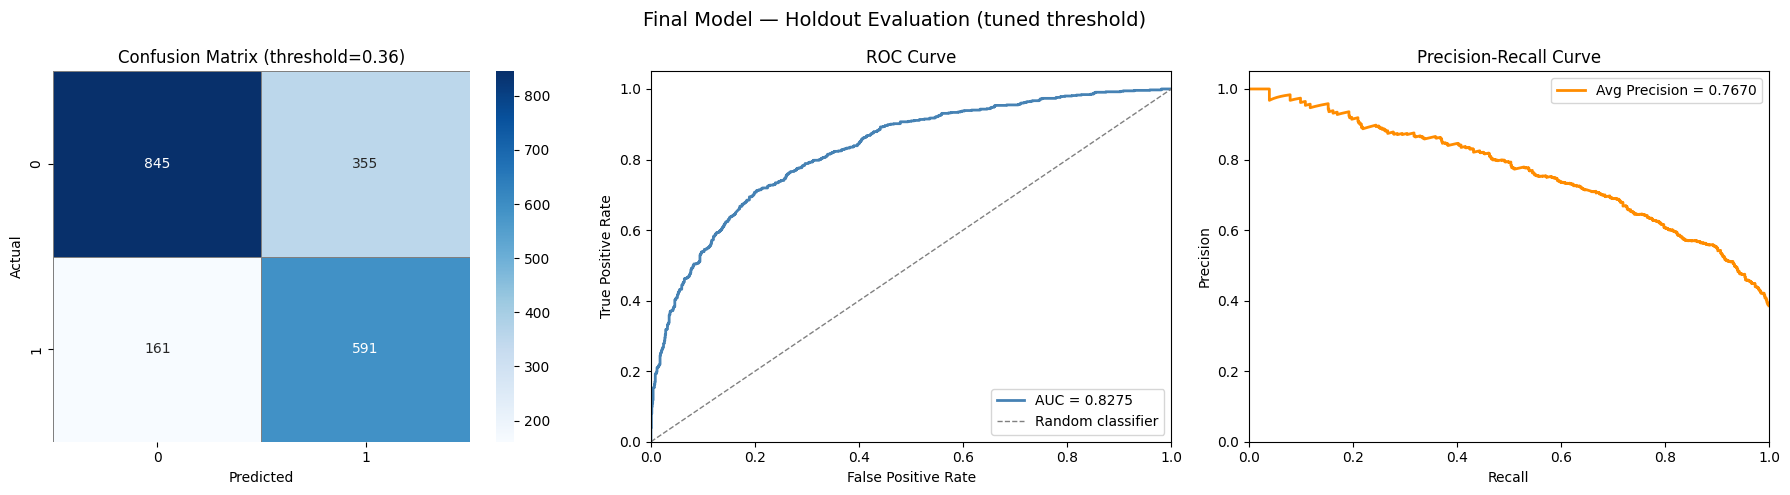

In [7]:
# best_estimator is already refit on all of X_train by GridSearchCV(refit=True)
final_model = best_estimator

holdout_default = evaluate_on_holdout(final_model, X_test, y_test, threshold=0.5)
holdout_tuned   = evaluate_on_holdout(final_model, X_test, y_test, threshold=best_threshold)

metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
holdout_compare = pd.DataFrame({
    "metric":          metrics,
    "holdout @ 0.5":   [holdout_default[m] for m in metrics],
    f"holdout @ {best_threshold:.2f}": [holdout_tuned[m] for m in metrics],
}).set_index("metric")
display(holdout_compare.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_confusion_matrix(holdout_tuned["confusion_matrix"],
                      title=f"Confusion Matrix (threshold={best_threshold:.2f})", ax=axes[0])
plot_roc_curve(y_test, holdout_tuned["y_prob"], title="ROC Curve", ax=axes[1])
plot_precision_recall_curve(y_test, holdout_tuned["y_prob"],
                             title="Precision-Recall Curve", ax=axes[2])
plt.suptitle("Final Model — Holdout Evaluation (tuned threshold)", fontsize=14)
plt.tight_layout()

---
## Section 8 — Results Summary

Consolidated comparison of **CV-best** (from the joint grid search in Section 3), **holdout @ 0.5**, and **holdout @ tuned threshold** across all metrics.

In [8]:
cv_best_f1 = tune_results_df["mean_test_score"].max()

summary_df = pd.DataFrame({
    "Metric":    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "CV best (F1-optimised)": ["—", "—", "—", f"{cv_best_f1:.4f}", "—"],
    "Holdout @ 0.5": [
        f"{holdout_default['accuracy']:.4f}",
        f"{holdout_default['precision']:.4f}",
        f"{holdout_default['recall']:.4f}",
        f"{holdout_default['f1']:.4f}",
        f"{holdout_default['roc_auc']:.4f}",
    ],
    f"Holdout @ {best_threshold:.2f}": [
        f"{holdout_tuned['accuracy']:.4f}",
        f"{holdout_tuned['precision']:.4f}",
        f"{holdout_tuned['recall']:.4f}",
        f"{holdout_tuned['f1']:.4f}",
        f"{holdout_tuned['roc_auc']:.4f}",
    ],
}).set_index("Metric")
display(summary_df)

,CV best (F1-optimised),Holdout @ 0.5,Holdout @ 0.36
Metric,,,
Accuracy,—,0.7649,0.7357
Precision,—,0.7096,0.6247
Recall,—,0.6596,0.7859
F1 Score,0.6801,0.6837,0.6961
ROC AUC,—,0.8275,0.8275


### Interpretation

Under `StratifiedGroupKFold`, the CV score is an **unbiased** estimate of generalisation performance — rotations of a source image no longer leak between folds, and the estimate should therefore be **lower** than the old leakage-prone CV numbers. The expected direction on holdout is therefore: **holdout F1 ≈ CV F1**, possibly a little below it (the holdout set is a single draw with its own variance). 

- If **holdout < CV**: the expected direction of an unbiased evaluation — CV gave a reasonable point estimate and the test set introduces some variance on top of it.
- If **holdout > CV**: the test set is comparatively easy, or small-sample variance is favourable. This is not a bug in the pipeline but it does mean the holdout number should not be over-interpreted — report both and lean on the CV estimate as the primary indicator of model quality.

Threshold tuning on out-of-fold probabilities changes the precision/recall trade-off without retraining the model. The `holdout @ 0.5` vs `holdout @ tuned` comparison isolates the effect of this decision-threshold choice.